In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
esm2 = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/ESM2_PCA_d512.tsv', sep='\t')
esm2


,gene_id,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,ENSG00000281990,3.314750,-1.118273,-0.943478,0.479634,-0.809435,0.222102,0.259368,1.210857,-0.814296,...,0.001016,-0.012886,-0.017434,-0.009363,-0.032523,-0.019058,-0.000206,-0.006558,-0.007576,0.008555
1,ENSG00000284631,-0.800070,0.374423,0.689806,-0.267924,-0.512693,2.369012,-0.482472,-0.527508,-0.938403,...,0.003974,-0.002601,0.032059,-0.016026,-0.020640,-0.010712,-0.022765,-0.008717,0.045518,-0.036628
2,ENSG00000102796,2.465040,0.783993,0.167619,0.158698,0.312217,-0.181124,-0.195503,0.554635,0.042476,...,0.033919,-0.004297,-0.050095,-0.044058,0.002157,0.023456,0.000003,0.001381,0.002809,0.005278
3,ENSG00000183981,1.058739,-1.218977,-1.514416,0.335829,-0.943254,0.912764,-0.191213,0.141463,0.534970,...,0.000365,-0.017221,-0.042750,0.000438,0.026847,0.000233,-0.003880,-0.017671,0.017881,0.019663
4,ENSG00000214978,-0.203057,-0.388987,-0.437602,-0.525312,-0.048112,-0.768311,-0.248356,-0.258288,-0.222785,...,0.031767,0.018073,-0.011524,-0.017049,0.028797,0.004218,-0.002097,-0.019356,-0.031878,-0.010899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20048,ENSG00000213015,-1.488946,0.759814,0.347521,-0.080264,-0.490965,-0.417309,-0.027300,0.047040,-0.458548,...,0.019573,-0.056332,-0.004521,0.022456,-0.037572,-0.008493,0.026408,0.004439,-0.005175,0.010395
20049,ENSG00000110880,1.048028,0.298055,0.925344,0.170562,-0.201423,-0.052164,0.095880,-0.186350,0.154340,...,-0.000410,0.020895,0.013001,-0.014929,0.011917,0.004860,0.015246,-0.010203,-0.004831,-0.009287
20050,ENSG00000173653,-2.519165,0.960641,0.357237,0.135407,-0.253040,-0.166413,0.397174,-0.026485,0.251901,...,0.010105,-0.014290,-0.002973,-0.002989,-0.010942,0.003455,-0.004565,0.006331,-0.010974,-0.003725
20051,ENSG00000136156,-0.765305,-0.727389,-0.562421,-0.658171,0.314070,-0.309731,0.085015,0.146014,0.466443,...,0.022179,-0.007449,0.004795,-0.004599,-0.003483,-0.015142,-0.009782,-0.002193,-0.016558,-0.006292


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
NCG_Known_Genes = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = esm2.merge(NCG_Known_Genes, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,0,1,2,3,4,5,6,7,8,9,...,506,507,508,509,510,511,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000105672,-1.991812,-1.282475,-0.420875,-0.577744,0.226034,0.241810,0.294443,-0.017896,0.235199,-0.275416,...,-0.033975,-0.012505,-0.018849,-0.005379,-0.018343,0.014970,False,False,False,False
ENSG00000180357,-2.162844,-0.466850,1.185446,-0.056920,0.148208,0.249521,1.103586,-0.530953,-0.219935,-0.065082,...,0.014986,-0.019793,-0.009137,0.010888,0.002041,0.023150,False,False,False,False
ENSG00000163466,-3.426574,0.081117,-0.018524,0.870734,0.264021,-0.349563,-0.281671,0.035409,-0.162845,0.345051,...,0.009052,-0.019932,0.010535,0.022944,0.011101,-0.005885,False,False,False,False
ENSG00000134070,-0.535278,-0.440051,-0.408251,-0.283681,-0.009761,-0.447197,0.319604,0.084457,0.278288,-0.169574,...,-0.017487,0.001133,-0.018723,-0.006499,-0.012105,0.005302,False,False,False,False
ENSG00000186792,0.863831,0.221589,-0.643094,-1.887985,0.056907,0.186894,-0.513291,0.198576,0.051266,-0.037487,...,0.033770,-0.012230,-0.028931,0.026019,-0.023817,0.002667,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000213015,-1.488946,0.759814,0.347521,-0.080264,-0.490965,-0.417309,-0.027300,0.047040,-0.458548,-0.193666,...,-0.037572,-0.008493,0.026408,0.004439,-0.005175,0.010395,False,False,False,False
ENSG00000110880,1.048028,0.298055,0.925344,0.170562,-0.201423,-0.052164,0.095880,-0.186350,0.154340,0.054850,...,0.011917,0.004860,0.015246,-0.010203,-0.004831,-0.009287,False,False,False,False
ENSG00000173653,-2.519165,0.960641,0.357237,0.135407,-0.253040,-0.166413,0.397174,-0.026485,0.251901,0.060936,...,-0.010942,0.003455,-0.004565,0.006331,-0.010974,-0.003725,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    12298
True       619
Name: count, dtype: int64

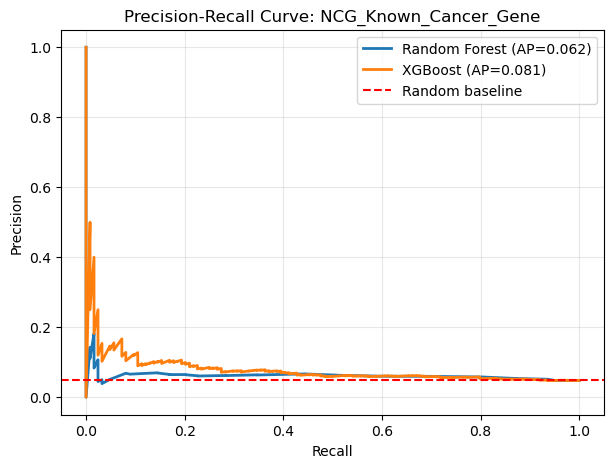

Random Forest - auPRC: 0.062
XGBoost - auPRC: 0.081



In [6]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11704
True      1213
Name: count, dtype: int64

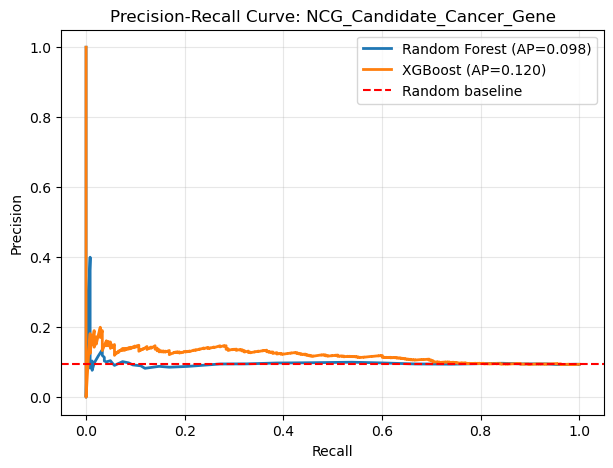

Random Forest - auPRC: 0.098
XGBoost - auPRC: 0.120



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    12429
True       488
Name: count, dtype: int64

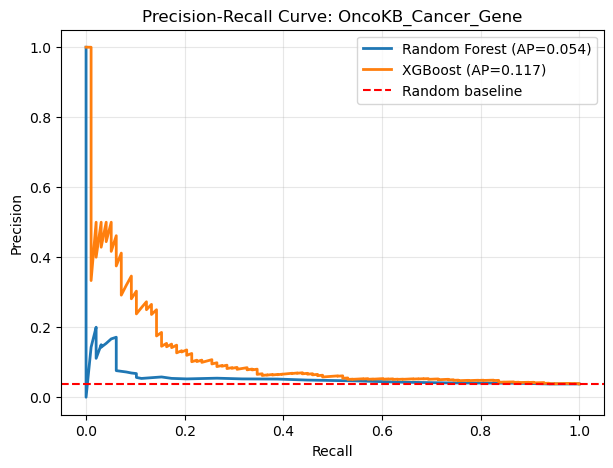

Random Forest - auPRC: 0.054
XGBoost - auPRC: 0.117



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12653
True       264
Name: count, dtype: int64

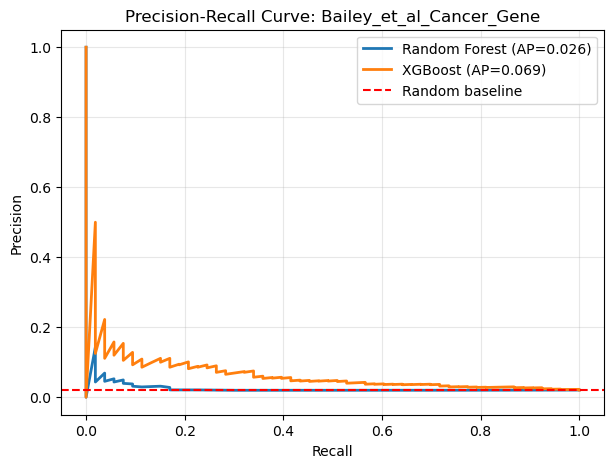

Random Forest - auPRC: 0.026
XGBoost - auPRC: 0.069



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')